### In this notebook, we compare the LFP signals obtained with a point source electrode to those obtained with a line source electrode, for a limited subset of the column

In [1]:
import numpy as np
import h5py
import pandas as pd
import bluepysnap as bp

In [2]:
import matplotlib.pyplot as plt
%matplotlib ipympl

In [3]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6
plt.rcParams["lines.linewidth"] = 0.5
plt.rcParams["axes.linewidth"] = 0.5
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 
plt.rcParams["xtick.minor.width"] = 0.5 
plt.rcParams["ytick.major.width"] = 0.5 
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

In [8]:
s = bp.Simulation('simulation_config_pointVLine.json')

In [9]:
population_name = s.reports['lfp_report'].population_names[0]

r  = s.reports['lfp_report'][population_name]

In [12]:
allData = r.get()

In [14]:
allData.columns = pd.MultiIndex.from_product((np.unique(allData.columns.get_level_values(0)),['PointSource','LineSource','Testing']),names=['gid','electrode'])


In [15]:
sumData = allData.groupby(axis=1, level='electrode').sum() # Sums over all neural LF contributions to get total signal


/tmp/ipykernel_1692792/4012139500.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sumData = allData.groupby(axis=1, level='electrode').sum() # Sums over all neural LF contributions to get total signal


In [16]:
savefig_cfg = {"transparent":True, "dpi": 300}
legend_cfg = {"frameon": False, "handletextpad": 0.1}
tight_layout_cfg = {"pad": 0.5}

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

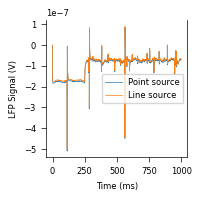

In [18]:
plt.figure(figsize=(2,2))
plt.plot(sumData['PointSource'])
plt.plot(sumData['LineSource'])
plt.xlabel('Time (ms)')
plt.ylabel('LFP Signal (V)')
plt.legend(['Point source','Line source'])
plt.tight_layout()
plt.savefig('pointVLine.svg')

### Next, we calculate the maximum difference between the two signals, relative to the amplitude value of the signal at the point of maximum difference 

In [14]:
difference = sumData['Finite']-sumData['Infinitesimal']

In [15]:
maxDiffIdx = np.argmax(np.abs(difference))

In [16]:
np.abs(difference).values[maxDiffIdx]/np.abs(sumData['Finite']).values[maxDiffIdx]

0.009940086